##Kudzu vine model

01 - Patch construction

**02 - Grid Search**

03 - PSO

04 - Simulation

05 - Map

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from scipy.optimize import minimize
import os
import zipfile
import warnings

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_patch_attributes_V5.csv")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i
0,0,100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0
1,1,100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0
2,2,100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0
3,3,100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0
4,4,100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0


In [ ]:
D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_D_ij_shortest_V5.npy")

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

Agriculture_prop = patch_df["Agriculture_prop"].to_numpy(dtype=float)
Forest_prop = patch_df["Forest_prop"].to_numpy(dtype=float)
Freshwater_prop = patch_df["Freshwater_prop"].to_numpy(dtype=float)
Marine_prop = patch_df["Marine_prop"].to_numpy(dtype=float)
Urban_prop = patch_df["Urban_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()

$$
\begin{aligned}
\alpha_i &= \alpha \\
y_i &= \sum_{k=1}^{5} p_{ik}y_k \\
e_i &= \sum_{k=1}^{5} p_{ik}e_k \\
x_i &= \sum_{k=1}^{5} p_{ik}x_k
\end{aligned}
$$

$$
k \in \{1,2,3,4,5\}
=
\{\mathrm{urban},\mathrm{agriculture},\mathrm{forest},\mathrm{freshwater},\mathrm{marine}\}
$$

$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$

    alpha_global

    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,

    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,

    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine


In [ ]:
patch_df.columns.tolist()

['patch_id',
 'cell_area',
 'land_area',
 'land_prop',
 'occyear1',
 'occyear2',
 'Agriculture_area',
 'Forest_area',
 'Freshwater_area',
 'Marine_area',
 'Urban_area',
 'Agriculture_prop',
 'Forest_prop',
 'Freshwater_prop',
 'Marine_prop',
 'Urban_prop',
 'A_i']

In [ ]:
## Define IFM function

def run_ifm_rmse(alpha_global,

                 y_Forest,
                 y_Agriculture,
                 y_Urban,
                 y_Freshwater,
                 y_Marine,

                 e_Forest,
                 e_Agriculture,
                 e_Urban,
                 e_Freshwater,
                 e_Marine,

                 x_Forest,
                 x_Agriculture,
                 x_Urban,
                 x_Freshwater,
                 x_Marine):

    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )

    # Connectivity kernel
    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)

    # Year 1
    S_i_year1 = K_ij @ (O_j * A_j)

    C_i_year1 = S_i_year1 ** 2 / (S_i_year1 ** 2 + y_i ** 2)

    E_i_year1 = np.minimum(e_i / (A_j ** x_i), 1.0)

    # Prediction for year 2
    p_i_year2 = C_i_year1 / (
        C_i_year1 + (1 - C_i_year1) * E_i_year1
    )

    # RMSE
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return rmse, p_i_year2, y_i, e_i, x_i

In [ ]:
### null model RMSE

rmse_null = np.sqrt(np.mean((obsyear2-0)**2))
print("Null model RMSE:", rmse_null)

Null model RMSE: 0.17654041535771625


In [ ]:
int(obsyear2.sum())

35

# Round 1

In [ ]:
%%time
parameter_results = []
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = np.inf
for alpha_global in [0.3, 0.9]:

    for y_Forest in [20, 80]:
        for y_Agriculture in [20, 80]:
            for y_Urban in [20, 80]:
                for y_Freshwater in [20, 80]:
                    for y_Marine in [20, 80]:
                        for e_Forest in [0.05, 0.8]:
                            for e_Agriculture in [0.05, 0.8]:
                                for e_Urban in [0.05, 0.8]:
                                    for e_Freshwater in [0.05, 0.8]:
                                        for e_Marine in [0.05, 0.8]:
                                            for x_Forest in [0.2, 1.5]:
                                                for x_Agriculture in [0.2, 1.5]:
                                                    for x_Urban in [0.2, 1.5]:
                                                        for x_Freshwater in [0.2, 1.5]:
                                                            for x_Marine in [0.2, 1.5]:
                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest,
                                                                    y_Agriculture,
                                                                    y_Urban,
                                                                    y_Freshwater,
                                                                    y_Marine,
                                                                    e_Forest,
                                                                    e_Agriculture,
                                                                    e_Urban,
                                                                    e_Freshwater,
                                                                    e_Marine,
                                                                    x_Forest,
                                                                    x_Agriculture,
                                                                    x_Urban,
                                                                    x_Freshwater,
                                                                    x_Marine
                                                                )
                                                                n_pred_year2 = (
                                                                    p_i_year2 > 0.5
                                                                ).sum()
                                                                grid_rmse_history.append(rmse)
                                                                best_rmse_so_far = min(best_rmse_so_far, rmse)
                                                                grid_best_history.append(best_rmse_so_far)
                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest,
                                                                    y_Agriculture,
                                                                    y_Urban,
                                                                    y_Freshwater,
                                                                    y_Marine,
                                                                    e_Forest,
                                                                    e_Agriculture,
                                                                    e_Urban,
                                                                    e_Freshwater,
                                                                    e_Marine,
                                                                    x_Forest,
                                                                    x_Agriculture,
                                                                    x_Urban,
                                                                    x_Freshwater,
                                                                    x_Marine,
                                                                    rmse,
                                                                    n_pred_year2
                                                                ))
parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[16],
        abs(z[17] - obsyear2.sum())
    )
)
print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)
for result in parameter_results_sorted[:100]:
    print(
        ", ".join(str(value) for value in result[:16])
        + f", {result[16]:.4f}, {result[17]}"
    )

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.3, 80, 80, 20, 20, 80, 0.05, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1613, 9
0.3, 20, 80, 80, 20, 80, 0.8, 0.8, 0.05, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1619, 10
0.3, 80, 80, 20, 20, 80, 0.05, 0.8, 0.8, 0.05, 0.05, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1620, 9
0.3, 80, 80, 20, 80, 80, 0.05, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1621, 7
0.3, 80, 80, 80, 20, 80, 0.05, 0.8, 0.05, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1621, 11
0.3, 80, 80, 80, 20, 80, 0.05, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1622, 8
0.3, 80, 80, 20, 20, 80, 0.8, 0.8, 0.05, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1622, 7
0.3, 20, 80, 80, 20, 80, 0.8, 0.8, 0.05, 0.8, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1623, 8
0.3, 20, 80, 80, 20, 80, 0.8, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1624, 8
0.3, 80,

In [ ]:
pd.Series(grid_rmse_history).describe()

,0
count,65536.000000
mean,0.208508
std,0.046771
min,0.161285
25%,0.176536
50%,0.176541
75%,0.239033
max,0.375189


In [ ]:
history_round1_df = pd.DataFrame({
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

history_round1_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_round1.csv", index=False)

In [ ]:
history_round1_df.describe()

,rmse,best_rmse
count,65536.000000,65536.000000
mean,0.208508,0.162536
std,0.046771,0.004457
min,0.161285,0.161285
25%,0.176536,0.161285
50%,0.176541,0.161285
75%,0.239033,0.161927
max,0.375189,0.236857


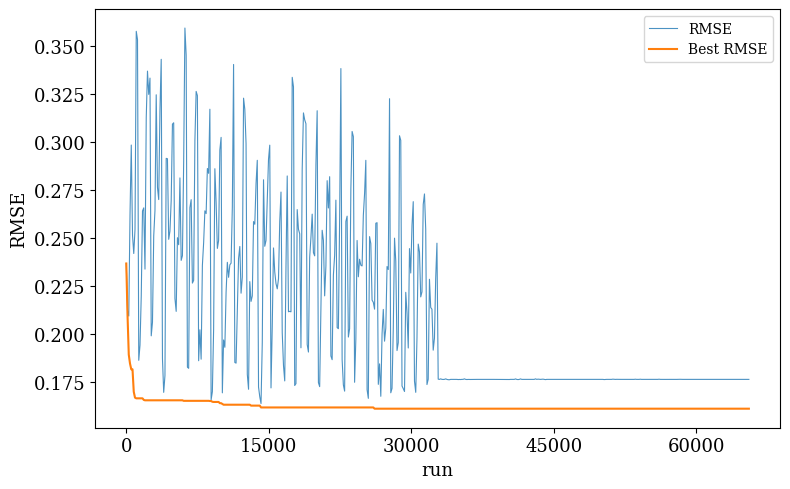

In [ ]:
from matplotlib.ticker import MaxNLocator

# plot 500 random results
sample_idx = np.linspace(
    0,
    len(history_round1_df) - 1,
    500,
    dtype=int
)

plot_df = history_round1_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("run", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()



---



## Round 2

In [ ]:
%%time
parameter_results = []
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = np.inf
for alpha_global in [0.3, 0.6]:
    for y_Forest in [50, 80]:
        for y_Agriculture in [50, 80]:
            for y_Urban in [20, 50]:
                for y_Freshwater in [20, 50]:
                    for y_Marine in [50, 80]:
                        for e_Forest in [0.05, 0.425]:
                            for e_Agriculture in [0.425, 0.8]:
                                for e_Urban in [0.425, 0.8]:
                                    for e_Freshwater in [0.05, 0.425]:
                                        for e_Marine in [0.425, 0.8]:
                                            for x_Forest in [0.2, 0.5]:
                                                for x_Agriculture in [0.5, 1.0]:
                                                    for x_Urban in [0.85, 1.5]:
                                                        for x_Freshwater in [0.85, 1.5]:
                                                            for x_Marine in [0.2, 0.85]:
                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine
                                                                )
                                                                n_pred_year2 = (p_i_year2 > 0.5).sum()
                                                                grid_rmse_history.append(rmse)
                                                                best_rmse_so_far = min(best_rmse_so_far, rmse)
                                                                grid_best_history.append(best_rmse_so_far)
                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine,
                                                                    rmse, n_pred_year2
                                                                ))
parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[16], abs(z[17] - obsyear2.sum()))
)
print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)
for result in parameter_results_sorted[:50]:
    print(", ".join(str(value) for value in result[:16]) + f", {result[16]:.4f}, {result[17]}")


# save history
history_round2_df = pd.DataFrame({
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})
history_round2_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_round2.csv", index=False)

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.3, 50, 80, 50, 20, 80, 0.425, 0.8, 0.8, 0.05, 0.8, 0.2, 0.5, 1.5, 1.5, 0.2, 0.1615, 8
0.3, 50, 80, 20, 20, 80, 0.425, 0.8, 0.425, 0.05, 0.8, 0.2, 0.5, 0.85, 1.5, 0.2, 0.1615, 7
0.3, 50, 80, 50, 20, 80, 0.425, 0.8, 0.8, 0.05, 0.425, 0.2, 0.5, 1.5, 1.5, 0.2, 0.1616, 8
0.3, 50, 80, 20, 20, 80, 0.425, 0.8, 0.425, 0.05, 0.425, 0.2, 0.5, 0.85, 1.5, 0.2, 0.1616, 7
0.3, 50, 80, 50, 20, 50, 0.425, 0.8, 0.8, 0.05, 0.8, 0.2, 0.5, 1.5, 1.5, 0.2, 0.1617, 8
0.3, 50, 80, 20, 20, 50, 0.425, 0.8, 0.425, 0.05, 0.8, 0.2, 0.5, 0.85, 1.5, 0.2, 0.1617, 7
0.3, 80, 80, 50, 20, 80, 0.05, 0.8, 0.8, 0.05, 0.8, 0.2, 0.5, 1.5, 1.5, 0.2, 0.1618, 9
0.3, 50, 80, 50, 20, 80, 0.425, 0.8, 0.425, 0.05, 0.8, 0.2, 0.5, 1.5, 1.5, 0.2, 0.1618, 8
0.3, 80, 80, 20, 20, 80, 0.05, 0.8, 0.425, 0.05, 0.8, 0.2, 0.5, 0.85, 1.5, 

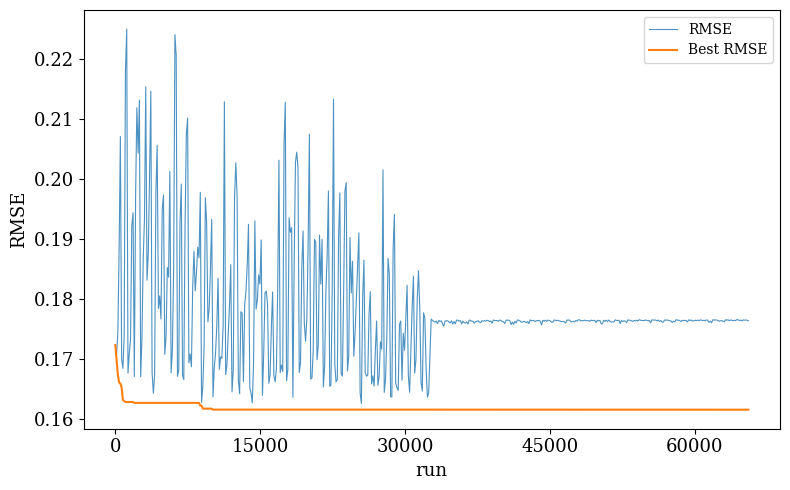

In [ ]:
## plot round 2 GS
sample_idx = np.linspace(
    0,
    len(history_round2_df) - 1,
    500,
    dtype=int
)

plot_df = history_round2_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)
plt.xlabel("run", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()



---



## Round 3 -1

In [ ]:
# 0.3,
# 50, 80, 20, 20, 80,
# 0.425, 0.8, 0.8, 0.05, 0.8,
# 0.2, 0.2, 1.5, 1.5, 0.2,

# 0.1611, 8

# 0.3, 50, 80, 50, 20, 80,
# 0.425, 0.8, 0.425, 0.05, 0.8,
# 0.2, 0.2, 1.5, 1.5, 0.2,
# 0.1611, 8
# 0.3, 50, 80, 50, 20, 80, 0.425, 0.425, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.5, 0.2, 0.1612, 8



In [ ]:
%%time

parameter_results = []


for alpha_global in [0.2, 0.4]:

    for y_Forest in [40, 60]:
        for y_Agriculture in [70, 90]:
            for y_Urban in [20, 40]:
                for y_Freshwater in [20, 30]:
                    for y_Marine in [70, 90]:

                        for e_Forest in [0.425, 0.625]:
                            for e_Agriculture in [0.7, 0.9]:
                                for e_Urban in [0.425, 0.8]:
                                    for e_Freshwater in [0.05, 0.1]:
                                        for e_Marine in [0.7, 0.9]:

                                            for x_Forest in [0.1, 0.3]:
                                                for x_Agriculture in [0.1, 0.3]:
                                                    for x_Urban in [1.25, 1.75]:
                                                        for x_Freshwater in [1.25, 1.75]:
                                                            for x_Marine in [0.1, 0.3]:

                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine
                                                                )

                                                                n_pred_year2 = (p_i_year2 > 0.5).sum()

                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine,
                                                                    rmse, n_pred_year2
                                                                ))

parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[16], abs(z[17] - obsyear2.sum()))
)

print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)

for result in parameter_results_sorted[:100]:
    print(", ".join(str(value) for value in result[:16]) + f", {result[16]:.4f}, {result[17]}")


 ### not very good

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.4, 40, 70, 20, 20, 90, 0.425, 0.7, 0.425, 0.05, 0.9, 0.3, 0.3, 1.75, 1.75, 0.1, 0.1637, 6
0.4, 40, 70, 20, 20, 90, 0.425, 0.7, 0.425, 0.05, 0.7, 0.3, 0.3, 1.75, 1.75, 0.1, 0.1637, 6
0.4, 40, 70, 20, 20, 90, 0.425, 0.7, 0.425, 0.05, 0.9, 0.3, 0.3, 1.75, 1.75, 0.3, 0.1637, 6
0.4, 40, 70, 20, 20, 70, 0.425, 0.7, 0.425, 0.05, 0.9, 0.3, 0.3, 1.75, 1.75, 0.1, 0.1637, 6
0.4, 40, 70, 20, 20, 90, 0.425, 0.7, 0.425, 0.05, 0.7, 0.3, 0.3, 1.75, 1.75, 0.3, 0.1637, 6
0.4, 40, 70, 20, 20, 70, 0.425, 0.7, 0.425, 0.05, 0.7, 0.3, 0.3, 1.75, 1.75, 0.1, 0.1637, 6
0.4, 40, 70, 20, 20, 70, 0.425, 0.7, 0.425, 0.05, 0.9, 0.3, 0.3, 1.75, 1.75, 0.3, 0.1637, 6
0.4, 40, 70, 20, 20, 70, 0.425, 0.7, 0.425, 0.05, 0.7, 0.3, 0.3, 1.75, 1.75, 0.3, 0.1638, 6
0.4, 40, 70, 20, 20, 90, 0.425, 0.7, 0.425, 0.1, 0.9, 0.3

## Round 3-2

In [ ]:
%%time
parameter_results = []
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = np.inf
for alpha_global in [0.3, 0.4]:
    for y_Forest in [40, 50]:
        for y_Agriculture in [70, 80]:
            for y_Urban in [20, 30]:
                for y_Freshwater in [20, 25]:
                    for y_Marine in [80, 90]:
                        for e_Forest in [0.425, 0.525]:
                            for e_Agriculture in [0.7, 0.8]:
                                for e_Urban in [0.425, 0.8]:
                                    for e_Freshwater in [0.05, 0.075]:
                                        for e_Marine in [0.8, 0.9]:
                                            for x_Forest in [0.2, 0.3]:
                                                for x_Agriculture in [0.2, 0.3]:
                                                    for x_Urban in [1.5, 1.75]:
                                                        for x_Freshwater in [1.5, 1.75]:
                                                            for x_Marine in [0.1, 0.2]:
                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine
                                                                )
                                                                n_pred_year2 = (p_i_year2 > 0.5).sum()
                                                                grid_rmse_history.append(rmse)
                                                                best_rmse_so_far = min(best_rmse_so_far, rmse)
                                                                grid_best_history.append(best_rmse_so_far)
                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine,
                                                                    rmse, n_pred_year2
                                                                ))
parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[16], abs(z[17] - obsyear2.sum()))
)
print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)
for result in parameter_results_sorted[:100]:
    print(", ".join(str(value) for value in result[:16]) + f", {result[16]:.4f}, {result[17]}")
history_round3_df = pd.DataFrame({
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})
history_round3_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_round3.csv", index=False)

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.3, 50, 80, 30, 20, 90, 0.425, 0.7, 0.8, 0.05, 0.9, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 80, 30, 20, 90, 0.425, 0.8, 0.8, 0.05, 0.9, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 80, 30, 20, 90, 0.425, 0.7, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 70, 30, 20, 90, 0.525, 0.8, 0.8, 0.05, 0.9, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 8
0.3, 50, 70, 30, 20, 90, 0.425, 0.8, 0.8, 0.05, 0.9, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 80, 30, 20, 90, 0.425, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 70, 30, 20, 90, 0.525, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 8
0.3, 50, 70, 30, 20, 90, 0.425, 0.8, 0.8, 0.05, 0.8, 0.2, 0.2, 1.5, 1.75, 0.1, 0.1607, 9
0.3, 50, 80, 30, 20, 80, 0.425, 0.7, 0.8, 0.05, 0.9, 0.2, 0.2, 1.5, 1.75, 0.1, 0.

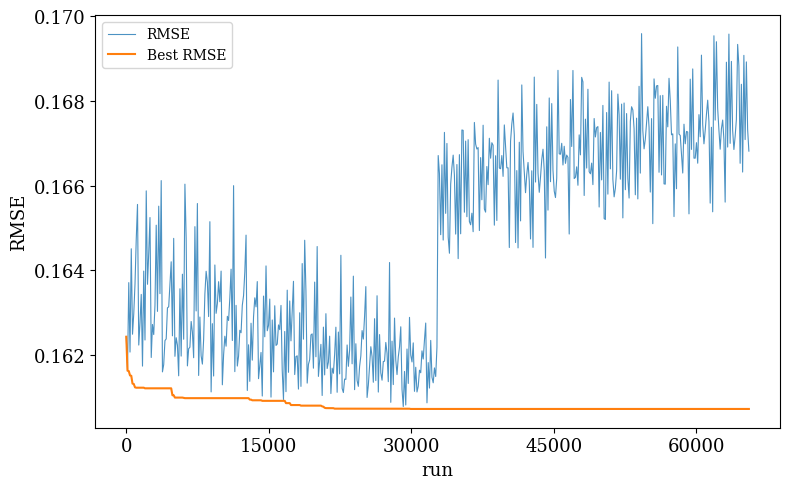

In [ ]:
## plot round 3 GS
sample_idx = np.linspace(
    0,
    len(history_round3_df) - 1,
    500,
    dtype=int
)

plot_df = history_round3_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("run", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 4

In [ ]:
%%time
parameter_results = []
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = np.inf
for alpha_global in [0.25, 0.30]:
    for y_Forest in [50, 55]:
        for y_Agriculture in [80, 85]:
            for y_Urban in [30, 35]:
                for y_Freshwater in [17.5, 20]:
                    for y_Marine in [90, 95]:
                        for e_Forest in [0.375, 0.425]:
                            for e_Agriculture in [0.65, 0.70]:
                                for e_Urban in [0.8, 0.9875]:
                                    for e_Freshwater in [0.0375, 0.05]:
                                        for e_Marine in [0.90, 0.95]:
                                            for x_Forest in [0.15, 0.20]:
                                                for x_Agriculture in [0.15, 0.20]:
                                                    for x_Urban in [1.375, 1.50]:
                                                        for x_Freshwater in [1.75, 1.875]:
                                                            for x_Marine in [0.05, 0.10]:
                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine
                                                                )
                                                                n_pred_year2 = (p_i_year2 > 0.5).sum()
                                                                grid_rmse_history.append(rmse)
                                                                best_rmse_so_far = min(best_rmse_so_far, rmse)
                                                                grid_best_history.append(best_rmse_so_far)
                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine,
                                                                    rmse, n_pred_year2
                                                                ))
parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[16], abs(z[17] - obsyear2.sum()))
)
print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)
for result in parameter_results_sorted[:100]:
    print(", ".join(str(value) for value in result[:16]) + f", {result[16]:.4f}, {result[17]}")
history_round4_df = pd.DataFrame({
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})
history_round4_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_round4.csv", index=False)

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.3, 55, 80, 30, 17.5, 95, 0.375, 0.65, 0.8, 0.0375, 0.95, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 55, 80, 30, 17.5, 95, 0.375, 0.65, 0.8, 0.0375, 0.9, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 50, 80, 30, 17.5, 95, 0.375, 0.65, 0.9875, 0.0375, 0.95, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 50, 80, 30, 17.5, 95, 0.375, 0.65, 0.9875, 0.0375, 0.9, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 55, 80, 30, 17.5, 90, 0.375, 0.65, 0.8, 0.0375, 0.95, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 55, 80, 30, 17.5, 95, 0.375, 0.65, 0.8, 0.0375, 0.95, 0.15, 0.2, 1.5, 1.875, 0.1, 0.1604, 9
0.3, 55, 80, 30, 17.5, 90, 0.375, 0.65, 0.8, 0.0375, 0.9, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3, 50, 80, 30, 17.5, 90, 0.375, 0.65, 0.9875, 0.0375, 0.95, 0.15, 0.2, 1.5, 1.875, 0.05, 0.1604, 9
0.3,

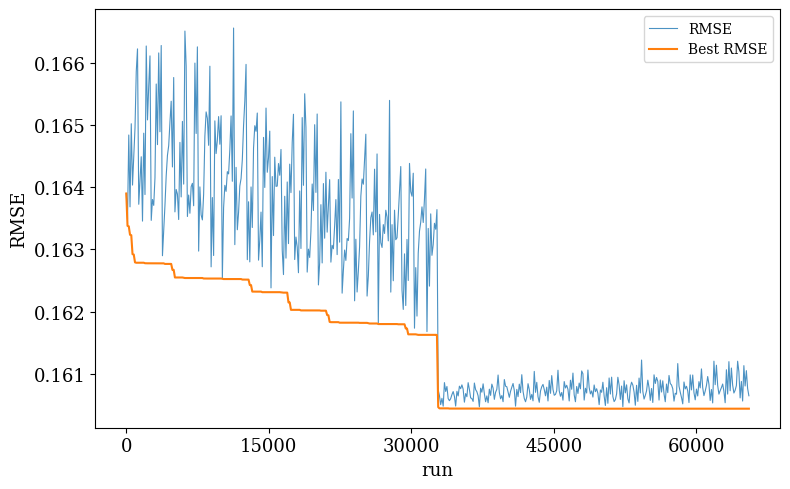

In [ ]:
## plot round 4 GS
sample_idx = np.linspace(
    0,
    len(history_round4_df) - 1,
    500,
    dtype=int
)

plot_df = history_round4_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("run", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 5

In [ ]:
%%time
parameter_results = []
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = np.inf
for alpha_global in [0.30, 0.325]:
    for y_Forest in [50, 55]:
        for y_Agriculture in [77.5, 80]:
            for y_Urban in [27.5, 30]:
                for y_Freshwater in [16.25, 17.5]:
                    for y_Marine in [90, 95]:
                        for e_Forest in [0.35, 0.375]:
                            for e_Agriculture in [0.625, 0.65]:
                                for e_Urban in [0.8, 0.9875]:
                                    for e_Freshwater in [0.03125, 0.0375]:
                                        for e_Marine in [0.90, 0.95]:
                                            for x_Forest in [0.125, 0.15]:
                                                for x_Agriculture in [0.20, 0.225]:
                                                    for x_Urban in [1.50, 1.5625]:
                                                        for x_Freshwater in [1.875, 1.9375]:
                                                            for x_Marine in [0.025, 0.05]:
                                                                rmse, p_i_year2, y_i, e_i, x_i = run_ifm_rmse(
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine
                                                                )
                                                                n_pred_year2 = (p_i_year2 > 0.5).sum()
                                                                grid_rmse_history.append(rmse)
                                                                best_rmse_so_far = min(best_rmse_so_far, rmse)
                                                                grid_best_history.append(best_rmse_so_far)
                                                                parameter_results.append((
                                                                    alpha_global,
                                                                    y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,
                                                                    e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,
                                                                    x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine,
                                                                    rmse, n_pred_year2
                                                                ))
parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[16], abs(z[17] - obsyear2.sum()))
)
print(
    "alpha_global, "
    "y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, "
    "e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, "
    "x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, "
    "rmse, n_pred_year2"
)
for result in parameter_results_sorted[:100]:
    print(", ".join(str(value) for value in result[:16]) + f", {result[16]:.4f}, {result[17]}")
history_round5_df = pd.DataFrame({
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})
history_round5_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_round5.csv", index=False)

alpha_global, y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine, e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine, x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine, rmse, n_pred_year2
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.65, 0.9875, 0.03125, 0.95, 0.125, 0.2, 1.5625, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.625, 0.9875, 0.03125, 0.95, 0.125, 0.225, 1.5, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.65, 0.9875, 0.03125, 0.95, 0.125, 0.225, 1.5, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.625, 0.9875, 0.03125, 0.95, 0.125, 0.2, 1.5625, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 30, 16.25, 95, 0.35, 0.625, 0.9875, 0.03125, 0.95, 0.125, 0.2, 1.5625, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.65, 0.9875, 0.03125, 0.9, 0.125, 0.2, 1.5625, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.5, 27.5, 16.25, 95, 0.35, 0.625, 0.9875, 0.03125, 0.9, 0.125, 0.225, 1.5, 1.9375, 0.025, 0.1603, 9
0.3, 55, 77.

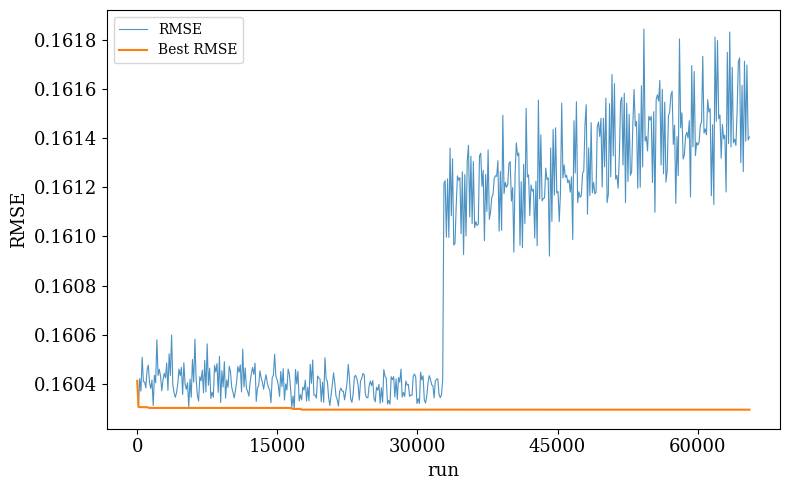

In [ ]:
## plot round 5 GS
sample_idx = np.linspace(
    0,
    len(history_round5_df) - 1,
    500,
    dtype=int
)

plot_df = history_round5_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("run", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
##################################################
## COMBINE RESULT

history_round1_df["Round"] = 1
history_round2_df["Round"] = 2
history_round3_df["Round"] = 3
history_round4_df["Round"] = 4
history_round5_df["Round"] = 5

history_all_df = pd.concat([
    history_round1_df,
    history_round2_df,
    history_round3_df,
    history_round4_df,
    history_round5_df
], ignore_index=True)

history_all_df["Global_evaluation"] = np.arange(1, len(history_all_df) + 1)

In [ ]:
history_all_df.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_kudzu_history_all.csv", index=False)

In [ ]:
history_all_df.head()

,rmse,best_rmse,Round,Global_evaluation
0,0.236857,0.236857,1,1
1,0.238396,0.236857,1,2
2,0.238917,0.236857,1,3
3,0.240467,0.236857,1,4
4,0.259439,0.236857,1,5


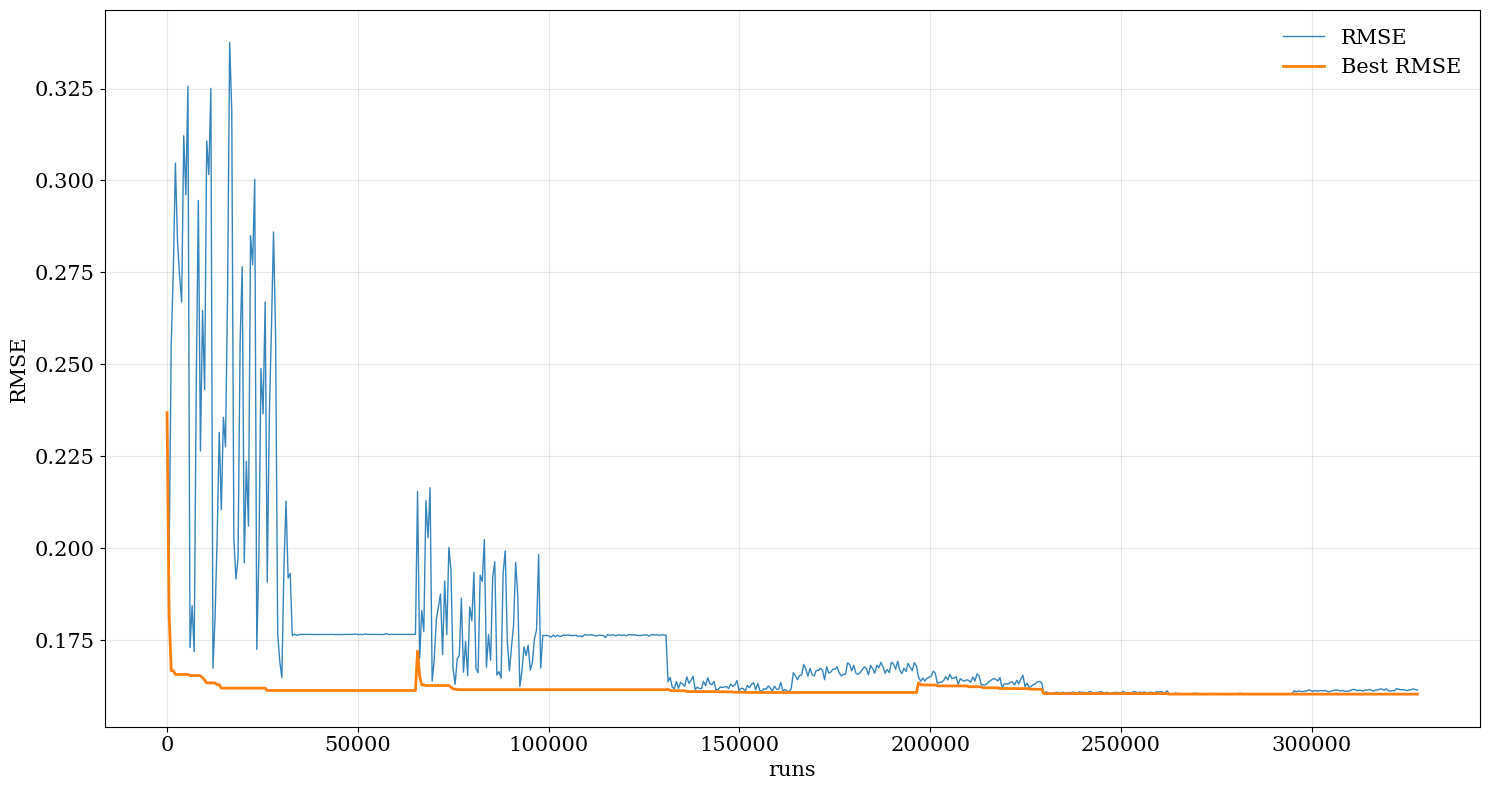

In [ ]:
## plot

sample_idx = np.linspace(
    0,
    len(history_all_df) - 1,
    600,
    dtype=int
)

history_sample_df = history_all_df.iloc[sample_idx]

plt.figure(figsize=(15, 8))

plt.plot(
    history_sample_df["Global_evaluation"],
    history_sample_df["rmse"],
    linewidth=1,
    alpha=0.9,
    label="RMSE"
)

plt.plot(
    history_sample_df["Global_evaluation"],
    history_sample_df["best_rmse"],
    linewidth=2,
    label="Best RMSE"
)

round_boundaries = (
    history_all_df.groupby("Round")["Global_evaluation"].max().values
)


plt.xlabel("runs", fontsize=15)
plt.ylabel("RMSE", fontsize=15)
plt.tick_params(labelsize=15)

plt.legend(
    frameon=False,
    fontsize=15
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
history_all_df.describe()

,rmse,best_rmse,Round,Global_evaluation
count,327680.000000,327680.000000,327680.000000,327680.000000
mean,0.174897,0.161342,3.000000,163840.500000
std,0.027918,0.002206,1.414216,94593.212441
min,0.160294,0.160294,1.000000,1.000000
25%,0.161259,0.160437,2.000000,81920.750000
50%,0.165092,0.161285,3.000000,163840.500000
75%,0.176442,0.161509,4.000000,245760.250000
max,0.375189,0.236857,5.000000,327680.000000




---



In [ ]:
#################################################################
##### BEST FITTING IN GRID SEARCH

landcover = [
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
]

param_table = pd.DataFrame({

    "y": [
        "55 (50)",
        "77.5 (80)",
        "27.5 (30)",
        "16.25",
        "95 (90)"
    ],

    "e": [
        "0.35",
        "0.65 (0.625)",
        "0.9875",
        "0.03125 (0.0375)",
        "0.95 (0.90)"
    ],

    "x": [
        "0.125",
        "0.20 (0.225)",
        "1.5625 (1.50)",
        "1.9375",
        "0.025 (0.05)"
    ]

}, index=landcover)

alpha_global = 0.3
rmse = 0.1603
n_pred_year2 = 9

param_table

,y,e,x
Forest,55 (50),0.35,0.125
Agriculture,77.5 (80),0.65 (0.625),0.20 (0.225)
Urban,27.5 (30),0.9875,1.5625 (1.50)
Freshwater,16.25,0.03125 (0.0375),1.9375
Marine,95 (90),0.95 (0.90),0.025 (0.05)


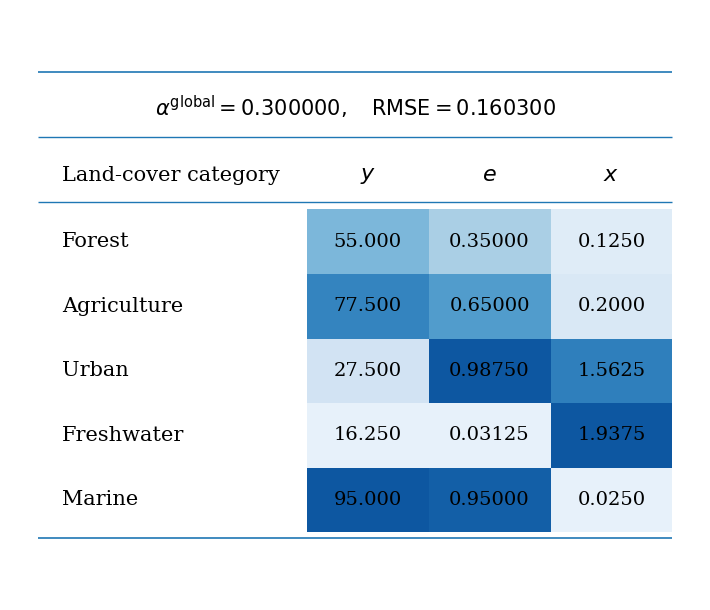

In [ ]:
## Plot
import matplotlib as mpl

landcover = [
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
]

values = np.array([
    [55.000, 0.35000, 0.1250],
    [77.500, 0.65000, 0.2000],
    [27.500, 0.98750, 1.5625],
    [16.250, 0.03125, 1.9375],
    [95.000, 0.95000, 0.0250]
])

alpha_global = 0.300000
rmse = 0.160300


mpl.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(7.2, 6.2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


left = 0.04
right = 0.96

label_left = 0.075

heat_left = 0.43
heat_right = 0.96

n_cols = 3
cell_w = (heat_right - heat_left) / n_cols


ax.hlines(
    0.895,
    left,
    right,
    linewidth=1.2
)


ax.text(
    0.5,
    0.835,
    rf"$\alpha^{{\mathrm{{global}}}} = {alpha_global:.6f},"
    rf"\quad \mathrm{{RMSE}} = {rmse:.6f}$",
    ha="center",
    va="center",
    fontsize=15
)

ax.hlines(
    0.785,
    left,
    right,
    linewidth=1.0
)


header_y = 0.72

ax.text(
    label_left,
    header_y,
    "Land-cover category",
    ha="left",
    va="center",
    fontsize=15
)

headers = [
    r"$y$",
    r"$e$",
    r"$x$"
]

for j, header in enumerate(headers):

    x = heat_left + (j + 0.5) * cell_w

    ax.text(
        x,
        header_y,
        header,
        ha="center",
        va="center",
        fontsize=16
    )

ax.hlines(
    0.675,
    left,
    right,
    linewidth=1.0
)

top = 0.662
bottom = 0.115

n_rows = len(landcover)
cell_h = (top - bottom) / n_rows

cmap = mpl.colormaps["Blues"]


norm_values = np.zeros_like(values, dtype=float)

for j in range(values.shape[1]):

    col = values[:, j]

    min_v = col.min()
    max_v = col.max()

    if max_v > min_v:
        norm_values[:, j] = (
            (col - min_v) /
            (max_v - min_v)
        )

norm_values = 0.08 + norm_values * 0.77

for i, category in enumerate(landcover):

    y_center = top - (i + 0.5) * cell_h
    y_bottom = top - (i + 1) * cell_h


    ax.text(
        label_left,
        y_center,
        category,
        ha="left",
        va="center",
        fontsize=15
    )

    for j in range(n_cols):

        x_left = heat_left + j * cell_w

        rect = mpl.patches.Rectangle(
            (x_left, y_bottom),
            cell_w,
            cell_h,
            facecolor=cmap(norm_values[i, j]),
            edgecolor="none"
        )

        ax.add_patch(rect)


        if j == 0:
            # y
            txt = f"{values[i, j]:.3f}"

        elif j == 1:
            # e
            txt = f"{values[i, j]:.5f}"

        else:
            # x
            txt = f"{values[i, j]:.4f}"

        ax.text(
            x_left + cell_w / 2,
            y_center,
            txt,
            ha="center",
            va="center",
            fontsize=14
        )

ax.hlines(
    bottom - 0.01,
    left,
    right,
    linewidth=1.2
)

plt.tight_layout()
plt.show()

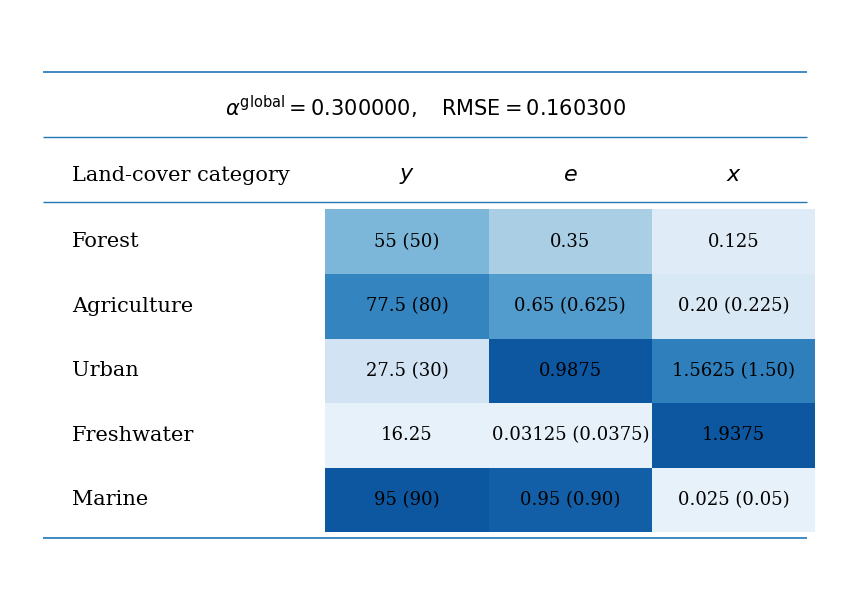

In [ ]:
## Plot
import matplotlib as mpl

landcover = [
    "Forest",
    "Agriculture",
    "Urban",
    "Freshwater",
    "Marine"
]

# Numeric values used for heatmap colouring
values = np.array([
    [55.000, 0.35000, 0.1250],
    [77.500, 0.65000, 0.2000],
    [27.500, 0.98750, 1.5625],
    [16.250, 0.03125, 1.9375],
    [95.000, 0.95000, 0.0250]
])

# Text shown in each cell
display_values = [
    ["55 (50)",       "0.35",              "0.125"],
    ["77.5 (80)",     "0.65 (0.625)",      "0.20 (0.225)"],
    ["27.5 (30)",     "0.9875",            "1.5625 (1.50)"],
    ["16.25",         "0.03125 (0.0375)",  "1.9375"],
    ["95 (90)",       "0.95 (0.90)",       "0.025 (0.05)"]
]

alpha_global = 0.300000
rmse = 0.160300

mpl.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(8.6, 6.2))

left = 0.04
right = 0.97
label_left = 0.07

heat_left = 0.38
heat_right = 0.97


ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

left = 0.04
right = 0.96
label_left = 0.075


n_cols = 3
cell_w = (heat_right - heat_left) / n_cols

# Top line
ax.hlines(
    0.895,
    left,
    right,
    linewidth=1.2
)

# Alpha and RMSE
ax.text(
    0.5,
    0.835,
    rf"$\alpha^{{\mathrm{{global}}}} = {alpha_global:.6f},"
    rf"\quad \mathrm{{RMSE}} = {rmse:.6f}$",
    ha="center",
    va="center",
    fontsize=15
)

ax.hlines(
    0.785,
    left,
    right,
    linewidth=1.0
)

# Header
header_y = 0.72

ax.text(
    label_left,
    header_y,
    "Land-cover category",
    ha="left",
    va="center",
    fontsize=15
)

headers = [
    r"$y$",
    r"$e$",
    r"$x$"
]

for j, header in enumerate(headers):

    x = heat_left + (j + 0.5) * cell_w

    ax.text(
        x,
        header_y,
        header,
        ha="center",
        va="center",
        fontsize=16
    )

ax.hlines(
    0.675,
    left,
    right,
    linewidth=1.0
)

# Table area
top = 0.662
bottom = 0.115

n_rows = len(landcover)
cell_h = (top - bottom) / n_rows

cmap = mpl.colormaps["Blues"]

# Normalize each parameter column independently
norm_values = np.zeros_like(values, dtype=float)

for j in range(values.shape[1]):

    col = values[:, j]

    min_v = col.min()
    max_v = col.max()

    if max_v > min_v:
        norm_values[:, j] = (
            (col - min_v) /
            (max_v - min_v)
        )

# Restrict colour intensity
norm_values = 0.08 + norm_values * 0.77

# Draw rows
for i, category in enumerate(landcover):

    y_center = top - (i + 0.5) * cell_h
    y_bottom = top - (i + 1) * cell_h

    ax.text(
        label_left,
        y_center,
        category,
        ha="left",
        va="center",
        fontsize=15
    )

    for j in range(n_cols):

        x_left = heat_left + j * cell_w

        rect = mpl.patches.Rectangle(
            (x_left, y_bottom),
            cell_w,
            cell_h,
            facecolor=cmap(norm_values[i, j]),
            edgecolor="none"
        )

        ax.add_patch(rect)

        # Display primary value and alternative value
        txt = display_values[i][j]

        ax.text(
            x_left + cell_w / 2,
            y_center,
            txt,
            ha="center",
            va="center",
            fontsize=13
        )

# Bottom line
ax.hlines(
    bottom - 0.01,
    left,
    right,
    linewidth=1.2
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Parameter": [
        "alpha_global",
        "y_Forest",
        "y_Agriculture",
        "y_Urban",
        "y_Freshwater",
        "y_Marine",
        "e_Forest",
        "e_Agriculture",
        "e_Urban",
        "e_Freshwater",
        "e_Marine",
        "x_Forest",
        "x_Agriculture",
        "x_Urban",
        "x_Freshwater",
        "x_Marine"
    ],

    "Round 1": [
        "[0.3, 0.9]",
        "[20, 80]",
        "[20, 80]",
        "[20, 80]",
        "[20, 80]",
        "[20, 80]",
        "[0.05, 0.8]",
        "[0.05, 0.8]",
        "[0.05, 0.8]",
        "[0.05, 0.8]",
        "[0.05, 0.8]",
        "[0.2, 1.5]",
        "[0.2, 1.5]",
        "[0.2, 1.5]",
        "[0.2, 1.5]",
        "[0.2, 1.5]"
    ],

    "Round 2": [
        "[0.3, 0.6]",
        "[50, 80]",
        "[50, 80]",
        "[20, 50]",
        "[20, 50]",
        "[50, 80]",
        "[0.05, 0.425]",
        "[0.425, 0.8]",
        "[0.425, 0.8]",
        "[0.05, 0.425]",
        "[0.425, 0.8]",
        "[0.2, 0.5]",
        "[0.5, 1.0]",
        "[0.85, 1.5]",
        "[0.85, 1.5]",
        "[0.2, 0.85]"
    ],

    "Round 3": [
        "[0.3, 0.4]",
        "[40, 50]",
        "[70, 80]",
        "[20, 30]",
        "[20, 25]",
        "[80, 90]",
        "[0.425, 0.525]",
        "[0.7, 0.8]",
        "[0.425, 0.8]",
        "[0.05, 0.075]",
        "[0.8, 0.9]",
        "[0.2, 0.3]",
        "[0.2, 0.3]",
        "[1.5, 1.75]",
        "[1.5, 1.75]",
        "[0.1, 0.2]"
    ],

    "Round 4": [
        "[0.25, 0.30]",
        "[50, 55]",
        "[80, 85]",
        "[30, 35]",
        "[17.5, 20]",
        "[90, 95]",
        "[0.375, 0.425]",
        "[0.65, 0.70]",
        "[0.8, 0.9875]",
        "[0.0375, 0.05]",
        "[0.90, 0.95]",
        "[0.15, 0.20]",
        "[0.15, 0.20]",
        "[1.375, 1.50]",
        "[1.75, 1.875]",
        "[0.05, 0.10]"
    ],

    "Round 5": [
        "[0.30, 0.325]",
        "[50, 55]",
        "[77.5, 80]",
        "[27.5, 30]",
        "[16.25, 17.5]",
        "[90, 95]",
        "[0.35, 0.375]",
        "[0.625, 0.65]",
        "[0.8, 0.9875]",
        "[0.03125, 0.0375]",
        "[0.90, 0.95]",
        "[0.125, 0.15]",
        "[0.20, 0.225]",
        "[1.50, 1.5625]",
        "[1.875, 1.9375]",
        "[0.025, 0.05]"
    ]
}

grid_ranges = pd.DataFrame(data)

grid_ranges

,Parameter,Round 1,Round 2,Round 3,Round 4,Round 5
0,alpha_global,"[0.3, 0.9]","[0.3, 0.6]","[0.3, 0.4]","[0.25, 0.30]","[0.30, 0.325]"
1,y_Forest,"[20, 80]","[50, 80]","[40, 50]","[50, 55]","[50, 55]"
2,y_Agriculture,"[20, 80]","[50, 80]","[70, 80]","[80, 85]","[77.5, 80]"
3,y_Urban,"[20, 80]","[20, 50]","[20, 30]","[30, 35]","[27.5, 30]"
4,y_Freshwater,"[20, 80]","[20, 50]","[20, 25]","[17.5, 20]","[16.25, 17.5]"
5,y_Marine,"[20, 80]","[50, 80]","[80, 90]","[90, 95]","[90, 95]"
6,e_Forest,"[0.05, 0.8]","[0.05, 0.425]","[0.425, 0.525]","[0.375, 0.425]","[0.35, 0.375]"
7,e_Agriculture,"[0.05, 0.8]","[0.425, 0.8]","[0.7, 0.8]","[0.65, 0.70]","[0.625, 0.65]"
8,e_Urban,"[0.05, 0.8]","[0.425, 0.8]","[0.425, 0.8]","[0.8, 0.9875]","[0.8, 0.9875]"
9,e_Freshwater,"[0.05, 0.8]","[0.05, 0.425]","[0.05, 0.075]","[0.0375, 0.05]","[0.03125, 0.0375]"


In [ ]:
grid_ranges.to_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/grid_search_ranges.csv",
    index=False)

In [ ]:
latex_table = grid_ranges.to_latex(
    index=False,
    escape=False,
    caption="Parameter ranges used across five rounds of grid search.",
    label="tab:grid_search_ranges"
)

print(latex_table)

\begin{table}
\caption{Parameter ranges used across five rounds of grid search.}
\label{tab:grid_search_ranges}
\begin{tabular}{llllll}
\toprule
Parameter & Round 1 & Round 2 & Round 3 & Round 4 & Round 5 \\
\midrule
alpha_global & [0.3, 0.9] & [0.3, 0.6] & [0.3, 0.4] & [0.25, 0.30] & [0.30, 0.325] \\
y_Forest & [20, 80] & [50, 80] & [40, 50] & [50, 55] & [50, 55] \\
y_Agriculture & [20, 80] & [50, 80] & [70, 80] & [80, 85] & [77.5, 80] \\
y_Urban & [20, 80] & [20, 50] & [20, 30] & [30, 35] & [27.5, 30] \\
y_Freshwater & [20, 80] & [20, 50] & [20, 25] & [17.5, 20] & [16.25, 17.5] \\
y_Marine & [20, 80] & [50, 80] & [80, 90] & [90, 95] & [90, 95] \\
e_Forest & [0.05, 0.8] & [0.05, 0.425] & [0.425, 0.525] & [0.375, 0.425] & [0.35, 0.375] \\
e_Agriculture & [0.05, 0.8] & [0.425, 0.8] & [0.7, 0.8] & [0.65, 0.70] & [0.625, 0.65] \\
e_Urban & [0.05, 0.8] & [0.425, 0.8] & [0.425, 0.8] & [0.8, 0.9875] & [0.8, 0.9875] \\
e_Freshwater & [0.05, 0.8] & [0.05, 0.425] & [0.05, 0.075] & [0.0375, 0.05

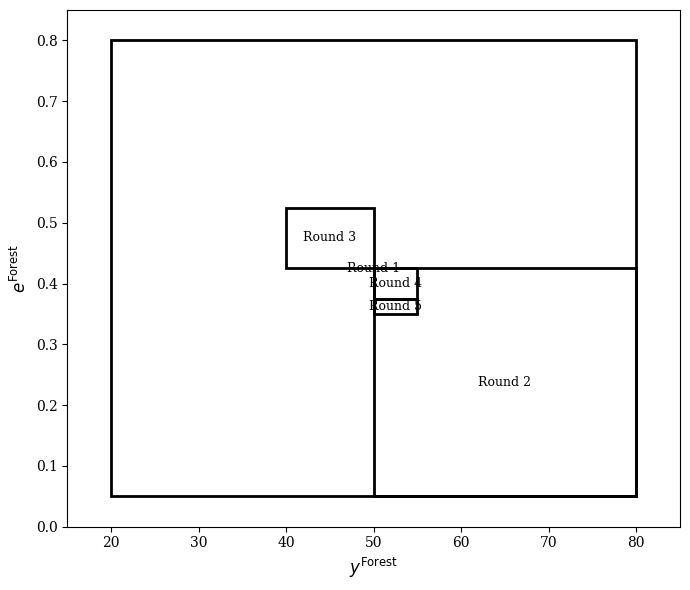

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Search ranges
rounds = {
    "Round 1": {
        "y": [20, 80],
        "e": [0.05, 0.8]
    },
    "Round 2": {
        "y": [50, 80],
        "e": [0.05, 0.425]
    },
    "Round 3": {
        "y": [40, 50],
        "e": [0.425, 0.525]
    },
    "Round 4": {
        "y": [50, 55],
        "e": [0.375, 0.425]
    },
    "Round 5": {
        "y": [50, 55],
        "e": [0.35, 0.375]
    }
}

fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, ranges) in enumerate(rounds.items()):

    y_min, y_max = ranges["y"]
    e_min, e_max = ranges["e"]

    rect = Rectangle(
        (y_min, e_min),
        y_max - y_min,
        e_max - e_min,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    # label each round
    ax.text(
        y_min + (y_max - y_min) / 2,
        e_min + (e_max - e_min) / 2,
        name,
        ha="center",
        va="center",
        fontsize=9
    )

ax.set_xlabel(r"$y^{\mathrm{Forest}}$", fontsize=12)
ax.set_ylabel(r"$e^{\mathrm{Forest}}$", fontsize=12)

ax.set_xlim(15, 85)
ax.set_ylim(0, 0.85)

ax.tick_params(labelsize=10)

plt.tight_layout()

plt.savefig(
    "grid_search_narrowing_forest.pdf",
    bbox_inches="tight"
)

plt.show()

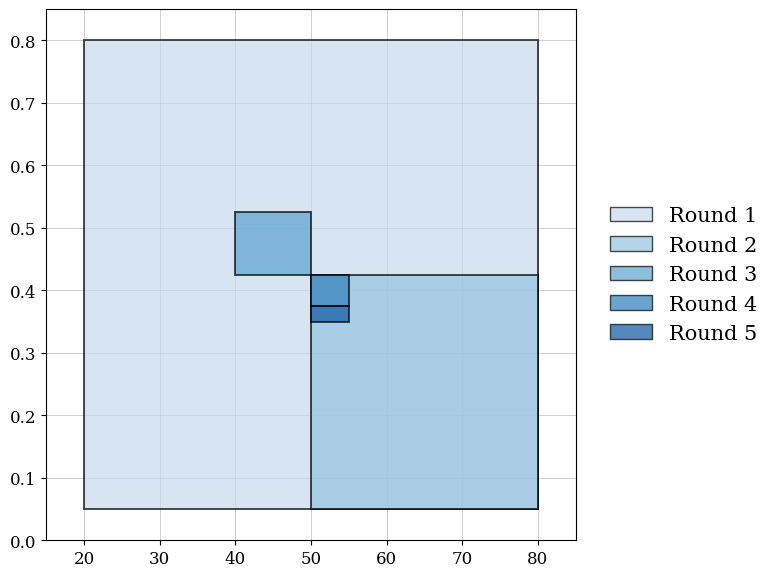

In [ ]:
from matplotlib.patches import Rectangle, Patch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15
})




# Search ranges
rounds = {
    "Round 1": {
        "y": [20, 80],
        "e": [0.05, 0.8]
    },
    "Round 2": {
        "y": [50, 80],
        "e": [0.05, 0.425]
    },
    "Round 3": {
        "y": [40, 50],
        "e": [0.425, 0.525]
    },
    "Round 4": {
        "y": [50, 55],
        "e": [0.375, 0.425]
    },
    "Round 5": {
        "y": [50, 55],
        "e": [0.35, 0.375]
    }
}

fig, ax = plt.subplots(figsize=(8, 6))


cmap = plt.cm.Blues
levels = np.linspace(0.25, 0.85, len(rounds))

legend_handles = []

for (name, ranges), level in zip(rounds.items(), levels):

    y_min, y_max = ranges["y"]
    e_min, e_max = ranges["e"]

    color = cmap(level)

    rect = Rectangle(
        (y_min, e_min),
        y_max - y_min,
        e_max - e_min,
        facecolor=color,
        edgecolor="black",
        linewidth=1.4,
        alpha=0.7
    )

    ax.add_patch(rect)

    legend_handles.append(
        Patch(
            facecolor=color,
            edgecolor="black",
            alpha=0.7,
            label=name
        )
    )



ax.set_xlim(15, 85)
ax.set_ylim(0, 0.85)

ax.set_xticks(np.arange(20, 90, 10))
ax.set_yticks(np.arange(0, 0.9, 0.1))

ax.grid(
    True,
    which="major",
    linewidth=0.7,
    alpha=0.6
)

ax.set_axisbelow(True)

ax.tick_params(labelsize=12)


ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.03, 0.5),
    frameon=False,
    fontsize=15,
    # title_fontsize=10
)

plt.tight_layout()

plt.savefig(
    "grid_search_narrowing_forest.pdf",
    bbox_inches="tight"
)

plt.show()



---



# Prediction

In [ ]:
    alpha_global

    y_Forest,
    y_Agriculture,
    y_Urban,
    y_Freshwater,
    y_Marine,

    e_Forest,
    e_Agriculture,
    e_Urban,
    e_Freshwater,
    e_Marine,

    x_Forest,
    x_Agriculture,
    x_Urban,
    x_Freshwater,
    x_Marine


In [ ]:
    # alpha_global,
    # y_Forest, y_Agriculture, y_Urban, y_Freshwater, y_Marine,

    # e_Forest, e_Agriculture, e_Urban, e_Freshwater, e_Marine,

    # x_Forest, x_Agriculture, x_Urban, x_Freshwater, x_Marine


In [ ]:
def run_ifm_forecast(alpha, y, e, x, n_steps):

    K_ij = np.exp(-alpha * D_ij)
    np.fill_diagonal(K_ij, 0)

    E_i = e / (A_j ** x)

    p_current = grid_land3035["occyear2"].to_numpy()

    forecast_results = []

    for step in range(1, n_steps + 1):

        S_i = K_ij @ (p_current * A_j)  ####

        C_i = ( S_i**2 / (S_i**2 + y**2))

        p_next = ( C_i / (C_i + E_i - C_i * E_i) )

        forecast_results.append((step, p_next))

        p_current = p_next

    return forecast_results


#----------------------------------------------------------------

forecast_results = run_ifm_forecast(
    alpha,
    y,
    e,
    x,
    n_steps=100
)


for step, p_next in forecast_results:

    n_pred = (p_next > 0.5).sum()

    print(
        step,
        n_pred,
        round(p_next.mean(),4),
        round(p_next.max(),4)
    )